In [5]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [16]:
#import libraries
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt



In [23]:
#Load the credit-card approval dataset
data = pd.read_csv("credit_card_approval.csv")

# View the first five records
print(data.head())

# Check the number of records and colums
print("Dataset shape:", data.shape)

#Check column names and data types
print(data.info())

#check missing values and duplciate records
print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicates:", data.duplicated().sum())

#check approval class distribution
print("\nApproved distribution:")
print(data["Approved"].value_counts())

     Age   Debt  Married  BankCustomer     Industry  YearsEmployed  \
0  30.83  0.000        1             1  Industrials           1.25   
1  58.67  4.460        1             1    Materials           3.04   
2  24.50  0.500        1             1    Materials           1.50   
3  27.83  1.540        1             1  Industrials           3.75   
4  20.17  5.625        1             1  Industrials           1.71   

   PriorDefault  Employed  CreditScore  DriversLicense       Citizen  ZipCode  \
0             1         1            1               0       ByBirth      202   
1             1         1            6               0       ByBirth       43   
2             1         0            0               0       ByBirth      280   
3             1         1            5               1       ByBirth      100   
4             1         0            0               0  ByOtherMeans      120   

   Income  Approved  
0       0         1  
1     560         1  
2     824         1  
3   

In [24]:
#Exclude sensitive/location columns for a more responsible model
features = ["Age", "Debt", "Married", "BankCustomer", "Industry", "YearsEmployed", "PriorDefault", "Employed",
            "CreditScore", "DriversLicense", "Citizen", "Income"]

#Input features/ predictors/ independent variables: X
X = data[features]

#Output label/outcome/dependent variahble: Y
y = data["Approved"]

print(X.head())
print(y.head())

     Age   Debt  Married  BankCustomer     Industry  YearsEmployed  \
0  30.83  0.000        1             1  Industrials           1.25   
1  58.67  4.460        1             1    Materials           3.04   
2  24.50  0.500        1             1    Materials           1.50   
3  27.83  1.540        1             1  Industrials           3.75   
4  20.17  5.625        1             1  Industrials           1.71   

   PriorDefault  Employed  CreditScore  DriversLicense       Citizen  Income  
0             1         1            1               0       ByBirth       0  
1             1         1            6               0       ByBirth     560  
2             1         0            0               0       ByBirth     824  
3             1         1            5               1       ByBirth       3  
4             1         0            0               0  ByOtherMeans       0  
0    1
1    1
2    1
3    1
4    1
Name: Approved, dtype: int64


In [25]:
#Split into training and test sets
#80% training datra, 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (552, 12)
X_test shape: (138, 12)
y_train shape: (552,)
y_test shape: (138,)


In [26]:
# List numerical and categorical comlumns
numeric_columns = [ "Age", "Debt", "YearsEmployed", "CreditScore", "Income"]
categorical_columns = [ "Married", "BankCustomer", "Industry", "PriorDefault", "Employed", "DriversLicense", "Citizen"]

#StandardScaler: standardise numerical features
#OneHotEncoder: convert categorical features to numerical columns
preprocessor = ColumnTransformer(transformers=[("numeric", StandardScaler(), numeric_columns),
                                               ("categorical", OneHotEncoder(handle_unknown="ignore"),categorical_columns)])

#learn the transformation from TRAINING data only
X_train_processed = preprocessor.fit_transform(X_train)

#apply the SAME transformation to TEST data
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (552, 32)
Processed testing shape: (138, 32)


In [29]:
models = { "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
          "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
          "Support Vector Machine": SVC(random_state=42),
          "Artifical Neural Network": MLPClassifier(random_state=42, max_iter=2000)}

results = []
trained_models = {}
predictions = {}

for name, model in models.items():

    #Train model using proecessed training data
    model.fit(X_train_processed, y_train)

    #predict outcomes using processed test data
    y_pred = model.predict(X_test_processed)

    #stored model and prediction
    trained_models[name] = model
    predictions[name] = y_pred

    #calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

    #Add results top comparison list
    results.append({"Model": name, "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-score": f1})

    print(f"\n{name}")
    print("Accuracy:", round(accuracy, 3))
    print("Precision:", round(precision, 3))
    print("Recall:", round(recall, 3))
    print("F1-score:", round(f1, 3))


Logistic Regression
Accuracy: 0.87
Precision: 0.852
Recall: 0.852
F1-score: 0.852


C:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\anaconda\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\anaconda\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\anaconda\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^


K-Nearest Neighbors
Accuracy: 0.855
Precision: 0.887
Recall: 0.77
F1-score: 0.825

Support Vector Machine
Accuracy: 0.884
Precision: 0.857
Recall: 0.885
F1-score: 0.871

Artifical Neural Network
Accuracy: 0.841
Precision: 0.882
Recall: 0.738
F1-score: 0.804


In [30]:
results_df = pd.DataFrame(results)

# Sort models from highest to lowest F1-score
results_df = results_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

print("\nModel Comparison Results:")
print(results_df.round(3))


Model Comparison Results:
                      Model  Accuracy  Precision  Recall  F1-score
0    Support Vector Machine     0.884      0.857   0.885     0.871
1       Logistic Regression     0.870      0.852   0.852     0.852
2       K-Nearest Neighbors     0.855      0.887   0.770     0.825
3  Artifical Neural Network     0.841      0.882   0.738     0.804


Best model: Support Vector Machine

Confusion Matrix:
[[68  9]
 [ 7 54]]


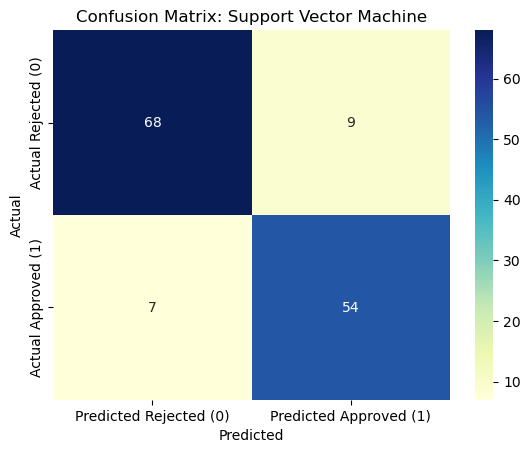

In [32]:
# Choose the model with the highest F1-score
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_prediction = predictions[best_model_name]

print("Best model:", best_model_name)

#Explicit label order:
# 0 = Rejected, 1 = Approved
cm = confusion_matrix(y_test, best_prediction, labels=[0, 1])

print("\nConfusion Matrix:")
print(cm)

# Display graph
sns.heatmap(
    cm,
    xticklabels=["Predicted Rejected (0)", "Predicted Approved (1)"],
    yticklabels=["Actual Rejected (0)", "Actual Approved (1)"],
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

In [33]:
# Save preprocessing object
joblib.dump(
    preprocessor,
    "credit_card_preprocessor.joblib"
)

# Save best trained classifier
joblib.dump(
    best_model,
    "credit_card_approval_best_model.joblib"
)

print("Preprocessor and best model saved successfully.")

Preprocessor and best model saved successfully.


In [34]:
# New applicant data
new_applicant = pd.DataFrame([{
    "Age": 30.83,
    "Debt": 0.00,
    "Married": 1,
    "BankCustomer": 1,
    "Industry": "Industrials",
    "YearsEmployed": 1.25,
    "PriorDefault": 1,
    "Employed": 1,
    "CreditScore": 1,
    "DriversLicense": 0,
    "Citizen": "ByBirth",
    "Income": 0
}])

# Apply the already-fitted preprocessor
new_applicant_processed = preprocessor.transform(new_applicant)

# Make new prediction using best model
prediction = best_model.predict(new_applicant_processed)[0]

if prediction == 1:
    print("Predicted approval decision: Approved")
else:
    print("Predicted approval decision: Rejected")

Predicted approval decision: Approved
